# Model Deployment
**Nama : Clarissa Beatrice Kosasih  
NIM : 2702209350**

> Goal : Mengenali booking yang kemungkinan besar dibatalkan sehingga hotel bisa meminimalkan rugi dari kamar yang dicancel.

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

In [66]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

In [67]:
data = pd.read_csv('Dataset_B_hotel.csv')
data.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0.0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0.0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0.0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0.0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0.0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [68]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     35368 non-null  object 
 6   required_car_parking_space            35005 non-null  float64
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

Dataset ini terdiri dari 19 kolom (2 kolom float, 12 kolom integer, dan 5 kolom object). Terdapat missing value di kolom

# Data Cleaning

## Handling Missing Value

In [69]:
# Hitung persentase NA tiap kolom
for col in data.columns:
  if data[col].isna().sum() > 0:
    print(f'{col}: {(data[col].isna().sum() / len(data[col]) * 100):.2f}%')

# Hitung jumlah baris dengan NA lebih dari 1 kolom
print(f'\nJumlah baris dengan NA lebih dari 1 kolom: {len(data[data.isna().sum(axis=1) > 1])}')

type_of_meal_plan: 2.50%
required_car_parking_space: 3.50%
avg_price_per_room: 4.50%

Jumlah baris dengan NA lebih dari 1 kolom: 135


Sebanyak 135 baris memiliki missing value di lebih dari satu kolom, yang mengindikasikan potensi keterkaitan antar kolom tersebut. Daripada melakukan imputasi yang bisa membuat hasil analisis menjadi kurang valid, penghapusan baris dinilai lebih tepat.

Karena persentase missing value di setiap kolom juga kurang dari 5%, maka baris-baris yang mengandung NA dihapus untuk menjaga kualitas data.

In [70]:
# Tampilan lengkap baris-baris dengan NA lebih dari 1 kolom
data[data.isna().sum(axis=1) > 1]

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
106,INN00107,2,0,1,4,NaN,1.0,Room_Type 1,10,2017,11,2,Online,0,0,0,NaN,0,Not_Canceled
846,INN00847,2,0,0,2,NaN,NaN,Room_Type 1,56,2017,9,17,Offline,0,0,0,82.00,0,Not_Canceled
1018,INN01019,2,0,0,2,Meal Plan 2,NaN,Room_Type 1,63,2017,9,4,Offline,0,0,0,NaN,0,Not_Canceled
1750,INN01751,2,0,2,1,NaN,0.0,Room_Type 1,61,2017,7,11,Online,0,0,0,NaN,0,Not_Canceled
1850,INN01851,2,0,2,4,NaN,NaN,Room_Type 1,169,2018,7,13,Offline,0,0,0,72.25,0,Not_Canceled
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35310,INN35311,2,0,3,7,NaN,0.0,Room_Type 1,261,2018,12,26,Online,0,0,0,NaN,0,Canceled
35458,INN35459,2,2,2,1,NaN,NaN,Room_Type 6,54,2018,4,16,Online,0,0,0,177.30,0,Canceled
35608,INN35609,2,0,1,2,NaN,NaN,Room_Type 1,135,2017,9,14,Offline,0,0,0,90.00,0,Not_Canceled
35964,INN35965,2,0,0,1,NaN,0.0,Room_Type 1,1,2017,12,31,Online,0,0,0,NaN,1,Not_Canceled


In [71]:
data = data.dropna()
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32607 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            32607 non-null  object 
 1   no_of_adults                          32607 non-null  int64  
 2   no_of_children                        32607 non-null  int64  
 3   no_of_weekend_nights                  32607 non-null  int64  
 4   no_of_week_nights                     32607 non-null  int64  
 5   type_of_meal_plan                     32607 non-null  object 
 6   required_car_parking_space            32607 non-null  float64
 7   room_type_reserved                    32607 non-null  object 
 8   lead_time                             32607 non-null  int64  
 9   arrival_year                          32607 non-null  int64  
 10  arrival_month                         32607 non-null  int64  
 11  arrival_date        

Sudah tidak ditemukan missing value.

## Handling Duplicates

In [72]:
# Drop duplicate
data = data.drop_duplicates()
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32607 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            32607 non-null  object 
 1   no_of_adults                          32607 non-null  int64  
 2   no_of_children                        32607 non-null  int64  
 3   no_of_weekend_nights                  32607 non-null  int64  
 4   no_of_week_nights                     32607 non-null  int64  
 5   type_of_meal_plan                     32607 non-null  object 
 6   required_car_parking_space            32607 non-null  float64
 7   room_type_reserved                    32607 non-null  object 
 8   lead_time                             32607 non-null  int64  
 9   arrival_year                          32607 non-null  int64  
 10  arrival_month                         32607 non-null  int64  
 11  arrival_date        

Tidak ada data yang duplikat.

# EDA

## Kolom dengan Unique Value

In [73]:
data.nunique()

,0
Booking_ID,32607
no_of_adults,5
no_of_children,6
no_of_weekend_nights,8
no_of_week_nights,18
type_of_meal_plan,4
required_car_parking_space,2
room_type_reserved,7
lead_time,349
arrival_year,2


`Booking_ID` berisikan unique value sehingga dapat memengaruhi performa machine learning. Maka dari itu, kolom `Booking_ID` akan didrop.

In [74]:
data = data.drop('Booking_ID', axis=1)
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32607 entries, 0 to 36274
Data columns (total 18 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   no_of_adults                          32607 non-null  int64  
 1   no_of_children                        32607 non-null  int64  
 2   no_of_weekend_nights                  32607 non-null  int64  
 3   no_of_week_nights                     32607 non-null  int64  
 4   type_of_meal_plan                     32607 non-null  object 
 5   required_car_parking_space            32607 non-null  float64
 6   room_type_reserved                    32607 non-null  object 
 7   lead_time                             32607 non-null  int64  
 8   arrival_year                          32607 non-null  int64  
 9   arrival_month                         32607 non-null  int64  
 10  arrival_date                          32607 non-null  int64  
 11  market_segment_type 

In [75]:
data.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0.0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,2,0,2,3,Not Selected,0.0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,1,0,2,1,Meal Plan 1,0.0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,2,0,0,2,Meal Plan 1,0.0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,2,0,1,1,Not Selected,0.0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


## Feature Engineering

### `total_no_of_nights`




In [76]:
data['total_no_of_nights'] = data['no_of_weekend_nights'] + data['no_of_week_nights']
data.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,total_no_of_nights
0,2,0,1,2,Meal Plan 1,0.0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled,3
1,2,0,2,3,Not Selected,0.0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled,5
2,1,0,2,1,Meal Plan 1,0.0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled,3
3,2,0,0,2,Meal Plan 1,0.0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled,2
4,2,0,1,1,Not Selected,0.0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled,2


Kolom ini dibuat untuk mengetahui total malam tamu menginap. Namun, `no_of_weekend_nights` dan `no_of_week_nights` tidak dihapus karena kadang model lebih akurat jika mengetahui pola weekend atau weekday.

## Distribusi Kolom Numeric

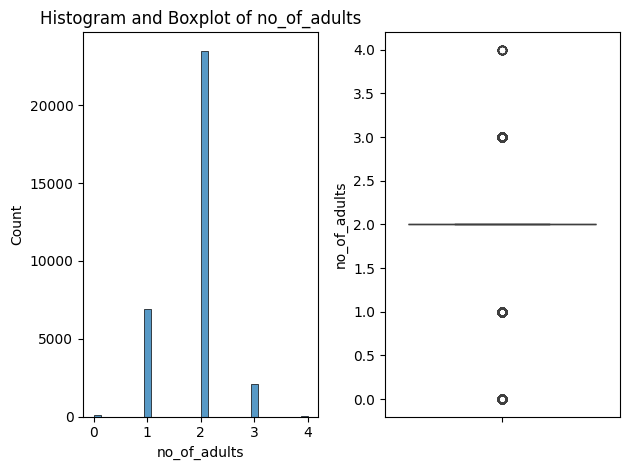

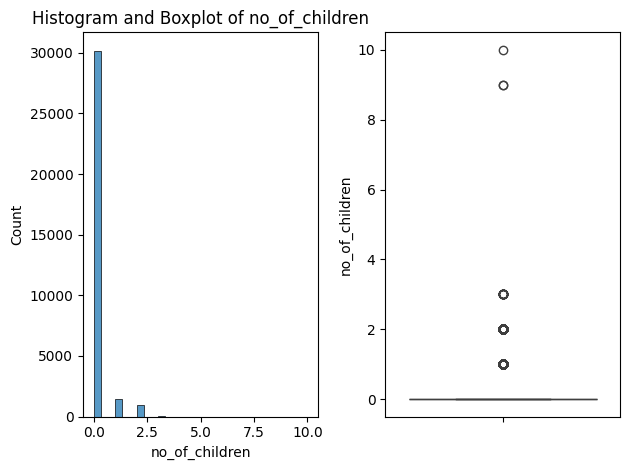

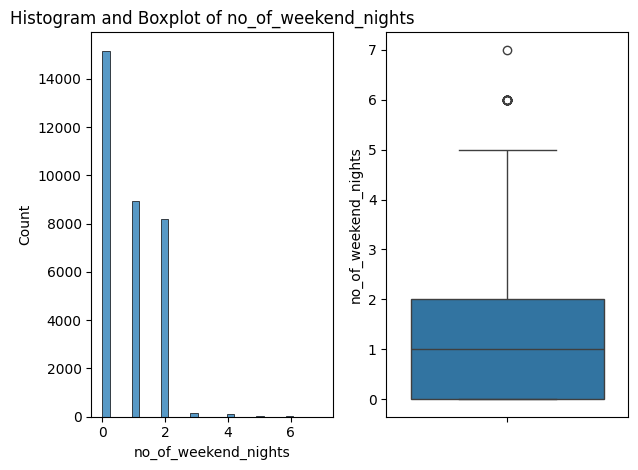

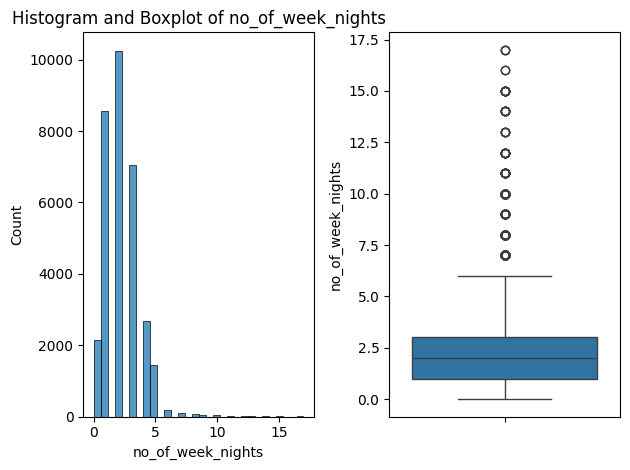

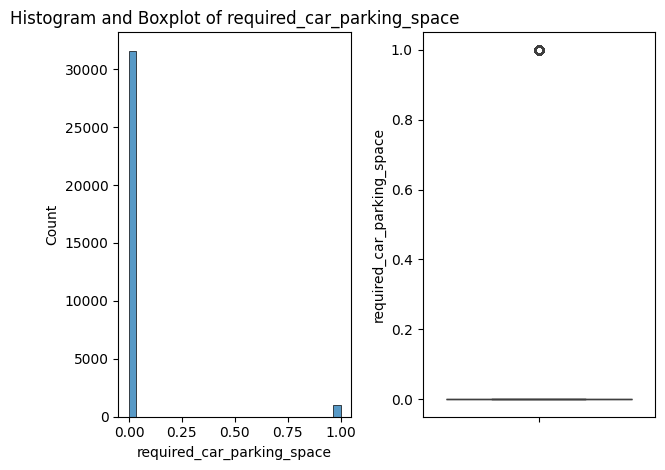

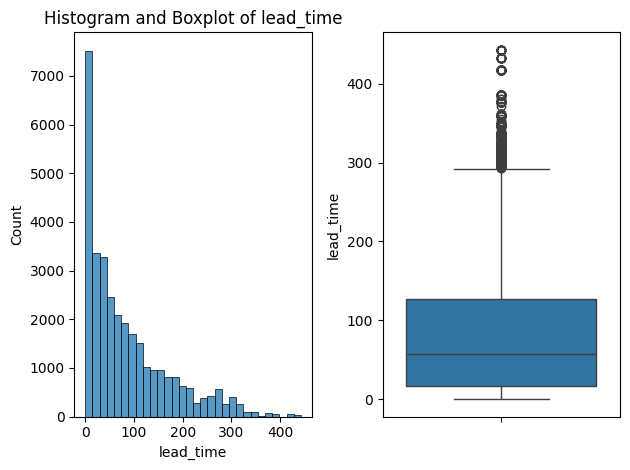

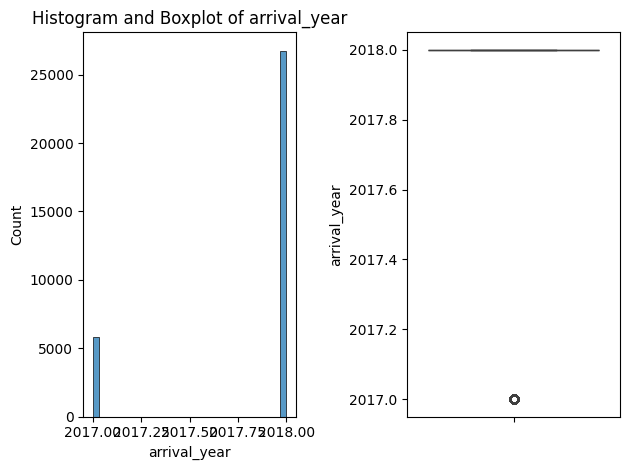

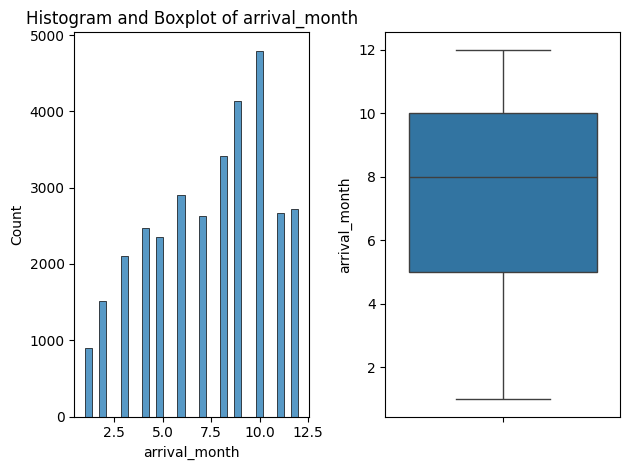

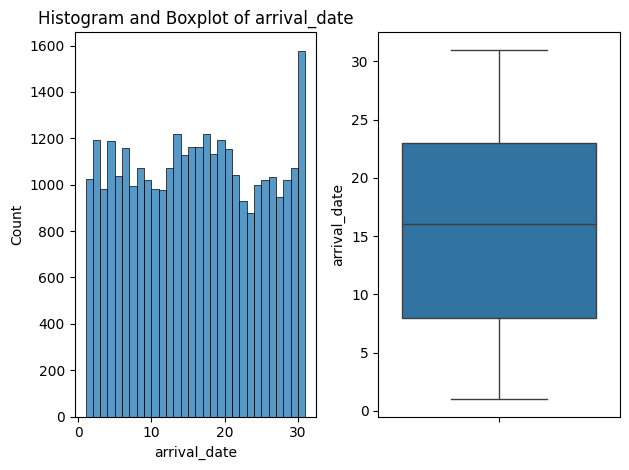

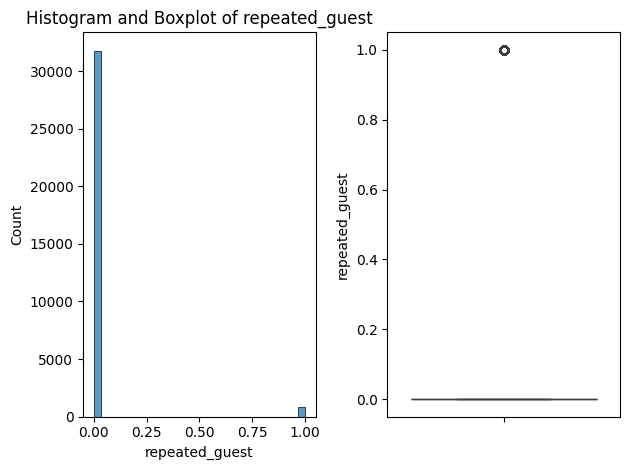

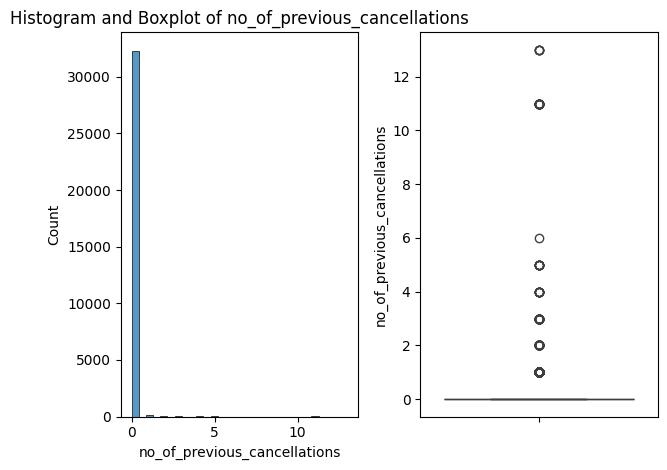

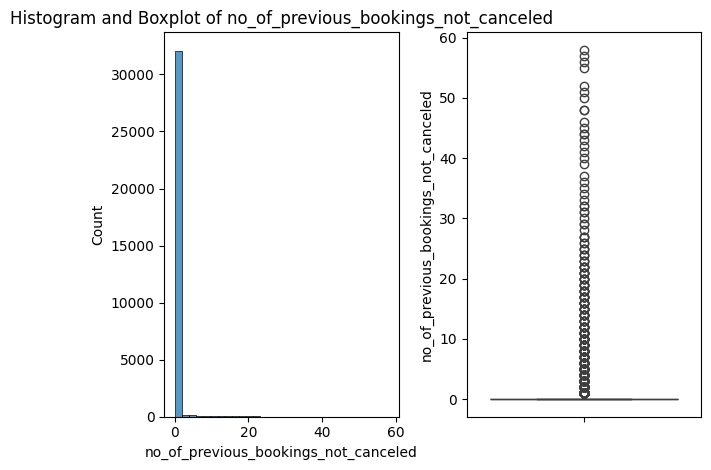

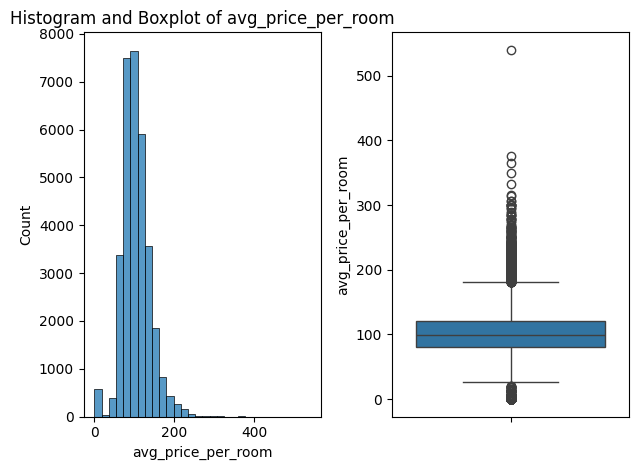

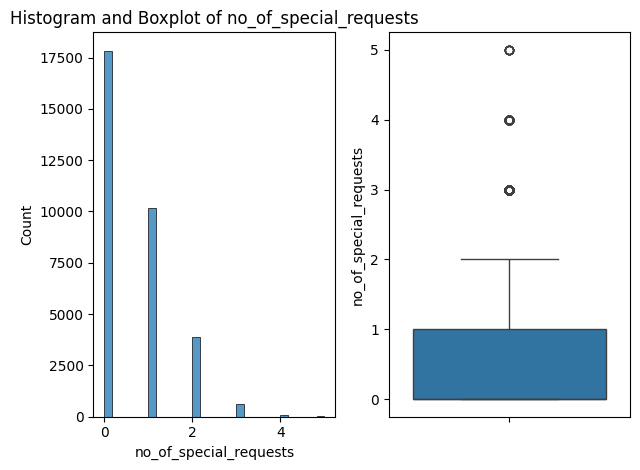

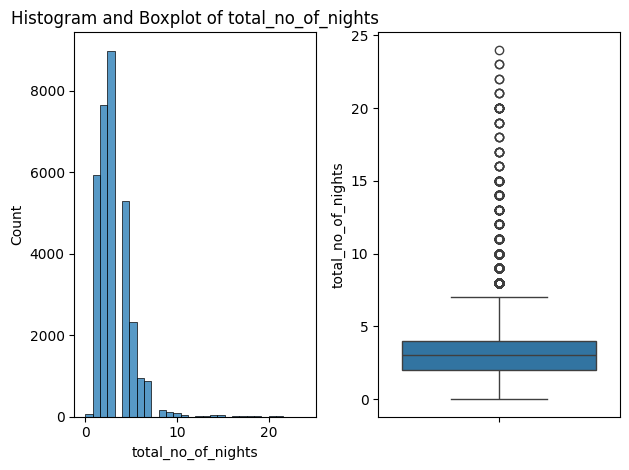

In [77]:
numerical_cols = data.select_dtypes(include=['number']).columns

for i in numerical_cols:
  plt.subplot(1,2,1)
  sns.histplot(data[i], bins = 30)
  plt.title(f"Histogram and Boxplot of {i}")

  plt.subplot(1,2,2)
  sns.boxplot(data[i])
  plt.tight_layout()
  plt.show()

Karena banyak kolom numerik mengandung outlier (meskipun kolom binary diabaikan), maka Robust Scaler dipilih untuk proses scaling karena lebih tahan terhadap outlier.

In [78]:
for col in numerical_cols:
  print(f"\n====== {col} ======")
  print(data[col].describe())


====== no_of_adults ======
count    32607.000000
mean         1.844880
std          0.517005
min          0.000000
25%          2.000000
50%          2.000000
75%          2.000000
max          4.000000
Name: no_of_adults, dtype: float64

====== no_of_children ======
count    32607.000000
mean         0.105008
std          0.402655
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         10.000000
Name: no_of_children, dtype: float64

====== no_of_weekend_nights ======
count    32607.000000
mean         0.811912
std          0.872569
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max          7.000000
Name: no_of_weekend_nights, dtype: float64

====== no_of_week_nights ======
count    32607.000000
mean         2.206029
std          1.417267
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         17.000000
Name: no_of_week_nights, dtype: float64

====== requir

Tidak ada nilai-nilai yang tidak masuk akal seperti nilai dibawah nol.

## Distribusi Kolom Categorical

In [79]:
categorical_cols = data.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
  print(data[col].value_counts())
  print("---------------------")

type_of_meal_plan
Meal Plan 1     25030
Not Selected     4589
Meal Plan 2      2983
Meal Plan 3         5
Name: count, dtype: int64
---------------------
room_type_reserved
Room_Type 1    25334
Room_Type 4     5431
Room_Type 6      863
Room_Type 2      600
Room_Type 5      235
Room_Type 7      137
Room_Type 3        7
Name: count, dtype: int64
---------------------
market_segment_type
Online           20836
Offline           9501
Corporate         1797
Complementary      361
Aviation           112
Name: count, dtype: int64
---------------------
booking_status
Not_Canceled    21876
Canceled        10731
Name: count, dtype: int64
---------------------


Tidak ada kesalahan eja atau typo. Akan tetapi, terdapat ketimpangan distribusi jumlah data, contohnya di 'Meal Plan 3' dan 'Room_Type 3' yang sangat sedikit dibanding kategori yang lainnya.

## Signifikansi Kolom terhadap Target : Kruskal Test

In [80]:
from scipy.stats import kruskal


def kruskal_test(data, numerical_cols):
  for col in numerical_cols:
    stat, p_value = kruskal(data[data['booking_status'] == 'Not_Canceled'][col],
                            data[data['booking_status'] == 'Canceled'][col])
    if p_value < 0.05:
      print(f"{col} is significant")
    else:
      print(f"{col} is not significant")

kruskal_test(data, numerical_cols)

no_of_adults is significant
no_of_children is significant
no_of_weekend_nights is significant
no_of_week_nights is significant
required_car_parking_space is significant
lead_time is significant
arrival_year is significant
arrival_month is significant
arrival_date is significant
repeated_guest is significant
no_of_previous_cancellations is significant
no_of_previous_bookings_not_canceled is significant
avg_price_per_room is significant
no_of_special_requests is significant
total_no_of_nights is significant


Semua kolom signifikan sehingga tidak ada yang di-drop.

# Before Training

## Encoding

Akan dilakukan encoding dengan teknik *label encoding*. Tidak dilakukan one-hot karena akan membuat banyak kolom baru dan boros memory.

In [81]:
encoders = {
    'type_of_meal_plan': {'Not Selected': 0, 'Meal Plan 1': 1, 'Meal Plan 2': 2, 'Meal Plan 3': 3},
    'room_type_reserved': {'Room_Type 1': 1, 'Room_Type 2': 2, 'Room_Type 3': 3,
                           'Room_Type 4': 4, 'Room_Type 5': 5, 'Room_Type 6': 6, 'Room_Type 7': 7},
    'market_segment_type': {'Online': 0, 'Offline': 1, 'Corporate': 2,
                            'Complementary': 3, 'Aviation': 4},
    'booking_status': {'Not_Canceled': 0, 'Canceled': 1}
}

In [82]:
for col, mapping in encoders.items():
    data[col] = data[col].replace(mapping)

<ipython-input-82-827084088d62>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[col] = data[col].replace(mapping)


In [83]:
for col in categorical_cols:
  print(data[col].value_counts())
  print("---------------------")

type_of_meal_plan
1    25030
0     4589
2     2983
3        5
Name: count, dtype: int64
---------------------
room_type_reserved
1    25334
4     5431
6      863
2      600
5      235
7      137
3        7
Name: count, dtype: int64
---------------------
market_segment_type
0    20836
1     9501
2     1797
3      361
4      112
Name: count, dtype: int64
---------------------
booking_status
0    21876
1    10731
Name: count, dtype: int64
---------------------


In [84]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32607 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   no_of_adults                          32607 non-null  int64  
 1   no_of_children                        32607 non-null  int64  
 2   no_of_weekend_nights                  32607 non-null  int64  
 3   no_of_week_nights                     32607 non-null  int64  
 4   type_of_meal_plan                     32607 non-null  int64  
 5   required_car_parking_space            32607 non-null  float64
 6   room_type_reserved                    32607 non-null  int64  
 7   lead_time                             32607 non-null  int64  
 8   arrival_year                          32607 non-null  int64  
 9   arrival_month                         32607 non-null  int64  
 10  arrival_date                          32607 non-null  int64  
 11  market_segment_type 

Semua kolom sudah dalam numeric.

## Data Splitting

In [85]:
from sklearn.model_selection import train_test_split

In [86]:
X = data.drop('booking_status', axis=1)
y = data['booking_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = SEED)

print(f"X_train : {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test : {y_test.shape}")

X_train : (26085, 18)
X_test : (6522, 18)
y_train : (26085,)
y_test : (6522,)


## Scaling
Karena Random Forest dan XGBoost berbasis pada Decision Tree, proses scaling tidak terlalu berpengaruh terhadap performa mereka.

# Training Model

In [87]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

## Random Forest

In [88]:
rf_model = RandomForestClassifier(random_state = SEED)

rf_model = rf_model.fit(X_train, y_train)
rf_y_pred = rf_model.predict(X_test)

In [89]:
# Evaluation Random Forest
labels = ['Not Canceled', 'Canceled']

print("Evaluation: RANDOM FOREST ==============")
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_y_pred))
print(f'\nClassification Report:\n{classification_report(y_test, rf_y_pred, target_names = labels)}')

Evaluation: RANDOM FOREST ==============
Confusion Matrix:
 [[4216  199]
 [ 424 1683]]

Classification Report:
              precision    recall  f1-score   support

Not Canceled       0.91      0.95      0.93      4415
    Canceled       0.89      0.80      0.84      2107

    accuracy                           0.90      6522
   macro avg       0.90      0.88      0.89      6522
weighted avg       0.90      0.90      0.90      6522



## XGBoost

In [90]:
xgb_model = XGBClassifier(random_state = SEED)

xgb_model = xgb_model.fit(X_train, y_train)
xgb_y_pred = xgb_model.predict(X_test)

In [91]:
print("Evaluation: XGBOOST ==============")
print("Confusion Matrix:\n", confusion_matrix(y_test, xgb_y_pred))
print(f'\nClassification Report:\n{classification_report(y_test, xgb_y_pred, target_names = labels)}')

Evaluation: XGBOOST ==============
Confusion Matrix:
 [[4162  253]
 [ 434 1673]]

Classification Report:
              precision    recall  f1-score   support

Not Canceled       0.91      0.94      0.92      4415
    Canceled       0.87      0.79      0.83      2107

    accuracy                           0.89      6522
   macro avg       0.89      0.87      0.88      6522
weighted avg       0.89      0.89      0.89      6522



Metrik penilaian utama untuk dataset ini adalah `Accuracy dan F1-Score`.
F1-Score dipilih karena mampu memberikan keseimbangan antara Precision dan Recall.

- Precision menjawab pertanyaan: "Dari semua yang diprediksi Canceled, berapa yang benar-benar Canceled?" (meminimalkan False Positive)

- Recall menjawab pertanyaan: "Dari semua yang benar-benar Canceled, berapa yang berhasil dideteksi oleh model?" (meminimalkan False Negative)

Dengan demikian, F1-Score menjadi metrik yang penting karena memperhitungkan keduanya secara seimbang, terutama jika data bersifat tidak seimbang (imbalanced).
Sementara itu, Accuracy tetap digunakan sebagai referensi umum untuk melihat performa model secara keseluruhan.

Model dengan performa terbaik adalah **Random Forest** karena f1-score untuk kedua kelas dan akurasi sedikit lebih tinggi dari XGBoost.

# Save as pickle

In [92]:
import pickle

In [93]:
rf_model = RandomForestClassifier(random_state = SEED)

rf_model = rf_model.fit(X_train, y_train)
rf_y_pred = rf_model.predict(X_test)